Epoch 1
Batch 312/312 - Loss: 43.88223
Epoch 1 - Average Loss: 0.0000


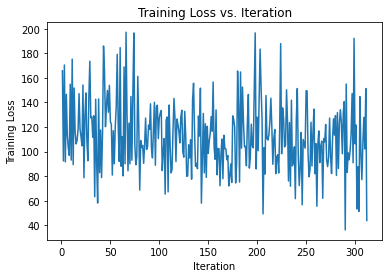

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Generate random data
d = 1000
N = 10000
X = np.random.rand(N, d)
theta = np.random.uniform(-2, 2, [d, 1])
y = X @ theta + 2
y = y.reshape(y.size,) + np.random.randn(y.size)

# Define the model
model = tf.keras.models.Sequential([tf.keras.layers.Dense(1, input_shape=[d], use_bias=False)])

# Compile the model
model.compile(optimizer='adam', loss="mse")

# Lists to store iteration and loss values
iterations = []
losses = []

# Custom training loop
batch_size = 32
num_batches = N // batch_size
for epoch in range(1):
    print("Epoch", epoch+1)
    epoch_loss = 0.0
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        X_batch = X[start_idx:end_idx]
        y_batch = y[start_idx:end_idx]

        # Train on batch
        batch_loss = model.train_on_batch(X_batch, y_batch)

        # Append iteration and loss
        iterations.append(epoch * num_batches + i + 1)
        losses.append(batch_loss)

        # Print progress
        print("\rBatch {}/{} - Loss: {:.4f}".format(i + 1, num_batches, batch_loss), end='')

    # Compute average epoch loss
    epoch_loss /= num_batches
    print("\nEpoch {} - Average Loss: {:.4f}".format(epoch + 1, epoch_loss))

# Plot the training loss
plt.plot(iterations, losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss vs. Iteration')
plt.show()
